## Analysis the Spacia result for  Microenvironment of Conical Mouse Brain

### Import the packages

In [4]:
import os, json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import product

### Result Directory

In [11]:
RESULT_FOLDERS = {
    "Astro_Excit": "/home/akram/share/Multiple_Grids/Spacia/Astro_Astro",
    "Astro_Endo": "/home/akram/share/Multiple_Grids/Spacia/Astro_Endo",
    "Astro_Micro": "/home/akram/share/Multiple_Grids/Spacia/Astro_Micro",
    "Astro_NeuExc": "/home/akram/share/Multiple_Grids/Spacia/Astro_NeuExc",
    "Astro_NeuInh": "/home/akram/share/Multiple_Grids/Spacia/Astro_NeuInh",
    "Astro_NeuMSN": "/home/akram/share/Multiple_Grids/Spacia/Astro_NeuMSN",
    "Astro_Oligo": "/home/akram/share/Multiple_Grids/Spacia/Astro_Oligo",
    "Astro_OPC": "/home/akram/share/Multiple_Grids/Spacia/Astro_OPC",
    "Astro_Pericyte": "/home/akram/share/Multiple_Grids/Spacia/Astro_Pericyte",
    "Astro_VLMC": "/home/akram/share/Multiple_Grids/Spacia/Astro_VLMC",

    "Bcell_Endo": "/home/akram/share/Multiple_Grids/Spacia/Bcell_Endo",
    "Bcell_Micro": "/home/akram/share/Multiple_Grids/Spacia/Bcell_Micro",
    "Bcell_NeuExc": "/home/akram/share/Multiple_Grids/Spacia/Bcell_NeuExc",
    "Bcell_NeuInh": "/home/akram/share/Multiple_Grids/Spacia/Bcell_NeuInh",
    "Bcell_NeuMSN": "/home/akram/share/Multiple_Grids/Spacia/Bcell_NeuMSN",
    "Bcell_Oligo": "/home/akram/share/Multiple_Grids/Spacia/Bcell_Oligo",
    "Bcell_OPC": "/home/akram/share/Multiple_Grids/Spacia/Bcell_OPC",
    "Bcell_Pericyte": "/home/akram/share/Multiple_Grids/Spacia/Bcell_Pericyte",

    "Endo_Astro": "/home/akram/share/Multiple_Grids/Spacia/Endo_Astro",
    "Endo_Endo": "/home/akram/share/Multiple_Grids/Spacia/Endo_Endo",
    "Endo_Micro": "/home/akram/share/Multiple_Grids/Spacia/Endo_Micro",
    "Endo_NeuExc": "/home/akram/share/Multiple_Grids/Spacia/Endo_NeuExc",
    "Endo_NeuInh": "/home/akram/share/Multiple_Grids/Spacia/Endo_NeuInh",
    "Endo_NeuMSN": "/home/akram/share/Multiple_Grids/Spacia/Endo_NeuMSN",
    "Endo_Oligo": "/home/akram/share/Multiple_Grids/Spacia/Endo_Oligo",
    "Endo_OPC": "/home/akram/share/Multiple_Grids/Spacia/Endo_OPC",
    "Endo_Pericyte": "/home/akram/share/Multiple_Grids/Spacia/Endo_Pericyte",
    "Endo_VLMC": "/home/akram/share/Multiple_Grids/Spacia/Endo_VLMC",

    "Epend_OPC": "/home/akram/share/Multiple_Grids/Spacia/Epend_OPC",

    "Macro_Astro": "/home/akram/share/Multiple_Grids/Spacia/Macro_Astro",
    "Macro_Endo": "/home/akram/share/Multiple_Grids/Spacia/Macro_Endo",
    "Macro_Micro": "/home/akram/share/Multiple_Grids/Spacia/Macro_Micro",
    "Macro_NeuExc": "/home/akram/share/Multiple_Grids/Spacia/Macro_NeuExc",
    "Macro_NeuInh": "/home/akram/share/Multiple_Grids/Spacia/Macro_NeuInh",
    "Macro_NeuMSN": "/home/akram/share/Multiple_Grids/Spacia/Macro_NeuMSN",
    "Macro_Oligo": "/home/akram/share/Multiple_Grids/Spacia/Macro_Oligo",
    "Macro_OPC": "/home/akram/share/Multiple_Grids/Spacia/Macro_OPC",
    "Macro_Pericyte": "/home/akram/share/Multiple_Grids/Spacia/Macro_Pericyte",
    "Macro_VLMC": "/home/akram/share/Multiple_Grids/Spacia/Macro_VLMC",

    "Micro_Astro": "/home/akram/share/Multiple_Grids/Spacia/Micro_Astro",
    "Micro_Endo": "/home/akram/share/Multiple_Grids/Spacia/Micro_Endo",
    "Micro_Micro": "/home/akram/share/Multiple_Grids/Spacia/Micro_Micro",
    "Micro_NeuExc": "/home/akram/share/Multiple_Grids/Spacia/Micro_NeuExc",
    "Micro_NeuInh": "/home/akram/share/Multiple_Grids/Spacia/Micro_NeuInh",
    "Micro_NeuMSN": "/home/akram/share/Multiple_Grids/Spacia/Micro_NeuMSN",
    "Micro_Oligo": "/home/akram/share/Multiple_Grids/Spacia/Micro_Oligo",
    "Micro_OPC": "/home/akram/share/Multiple_Grids/Spacia/Micro_OPC", 
    "Micro_Pericyte": "/home/akram/share/Multiple_Grids/Spacia/Micro_Pericyte", #--------------
    "Micro_VLMC": "/home/akram/share/Multiple_Grids/Spacia/Micro_VLMC", #--------------

    "NeuExc_Astro": "/home/akram/share/Multiple_Grids/Spacia/NeuExc_Astro",
    "NeuExc_Endo": "/home/akram/share/Multiple_Grids/Spacia/NeuExc_Endo",
    "NeuExc_Micro": "/home/akram/share/Multiple_Grids/Spacia/NeuExc_Micro",
    "NeuExc_NeuExc": "/home/akram/share/Multiple_Grids/Spacia/NeuExc_NeuExc",
    "NeuExc_NeuInh": "/home/akram/share/Multiple_Grids/Spacia/NeuExc_NeuInh",
    "NeuExc_NeuMSN": "/home/akram/share/Multiple_Grids/Spacia/NeuExc_NeuMSN",
    "NeuExc_Oligo": "/home/akram/share/Multiple_Grids/Spacia/NeuExc_Oligo",
    "NeuExc_OPC": "/home/akram/share/Multiple_Grids/Spacia/NeuExc_OPC",
    "NeuExc_Pericyte": "/home/akram/share/Multiple_Grids/Spacia/NeuExc_Pericyte",

    "NeuInh_Astro": "/home/akram/share/Multiple_Grids/Spacia/NeuInh_Astro",
    "NeuInh_Endo": "/home/akram/share/Multiple_Grids/Spacia/NeuInh_Endo",
    "NeuInh_Micro": "/home/akram/share/Multiple_Grids/Spacia/NeuInh_Micro",
    "NeuInh_NeuExc": "/home/akram/share/Multiple_Grids/Spacia/NeuInh_NeuExc",
    "NeuInh_NeuInh": "/home/akram/share/Multiple_Grids/Spacia/NeuInh_NeuInh",
    "NeuInh_NeuMSN": "/home/akram/share/Multiple_Grids/Spacia/NeuInh_NeuMSN",
    "NeuInh_Oligo": "/home/akram/share/Multiple_Grids/Spacia/NeuInh_Oligo",
    "NeuInh_OPC": "/home/akram/share/Multiple_Grids/Spacia/NeuInh_OPC",
    "NeuInh_Pericyte": "/home/akram/share/Multiple_Grids/Spacia/NeuInh_Pericyte",
    "NeuInh_VLMC": "/home/akram/share/Multiple_Grids/Spacia/NeuInh_VLMC",

    "NeuMSN_Astro": "/home/akram/share/Multiple_Grids/Spacia/NeuMSN_Astro",
    "NeuMSN_Endo": "/home/akram/share/Multiple_Grids/Spacia/NeuMSN_Endo",
    "NeuMSN_Micro": "/home/akram/share/Multiple_Grids/Spacia/NeuMSN_Micro",
    "NeuMSN_NeuExc": "/home/akram/share/Multiple_Grids/Spacia/NeuMSN_NeuExc",
    "NeuMSN_NeuInh": "/home/akram/share/Multiple_Grids/Spacia/NeuMSN_NeuInh",
    "NeuMSN_NeuMSN": "/home/akram/share/Multiple_Grids/Spacia/NeuMSN_NeuMSN",
    "NeuMSN_Oligo": "/home/akram/share/Multiple_Grids/Spacia/NeuMSN_Oligo",
    "NeuMSN_OPC": "/home/akram/share/Multiple_Grids/Spacia/NeuMSN_OPC",
    "NeuMSN_Pericyte": "/home/akram/share/Multiple_Grids/Spacia/NeuMSN_Pericyte",
    "NeuMSN_VLMC": "/home/akram/share/Multiple_Grids/Spacia/NeuMSN_VLMC",

    "Neuroblast_Astro": "/home/akram/share/Multiple_Grids/Spacia/Neuroblast_Astro",
    "Neuroblast_Micro": "/home/akram/share/Multiple_Grids/Spacia/Neuroblast_Micro",
    "Neuroblast_NeuExc": "/home/akram/share/Multiple_Grids/Spacia/Neuroblast_NeuExc",
    "Neuroblast_NeuInh": "/home/akram/share/Multiple_Grids/Spacia/Neuroblast_NeuInh",
    "Neuroblast_NeuMSN": "/home/akram/share/Multiple_Grids/Spacia/Neuroblast_NeuMSN",
    "Neuroblast_Oligo": "/home/akram/share/Multiple_Grids/Spacia/Neuroblast_Oligo",
    "Neuroblast_OPC": "/home/akram/share/Multiple_Grids/Spacia/Neuroblast_OPC",
    "Neuroblast_Pericyte": "/home/akram/share/Multiple_Grids/Spacia/Neuroblast_Pericyte",
    "Neuroblast_VLMC": "/home/akram/share/Multiple_Grids/Spacia/Neuroblast_VLMC",

    "NSC_Astro": "/home/akram/share/Multiple_Grids/Spacia/NSC_Astro",
    "NSC_Neuroblast": "/home/akram/share/Multiple_Grids/Spacia/NSC_Neuroblast",
    "NSC_NSC": "/home/akram/share/Multiple_Grids/Spacia/NSC_NSC",
    "NSC_Oligo": "/home/akram/share/Multiple_Grids/Spacia/NSC_Oligo",
    "NSC_OPC": "/home/akram/share/Multiple_Grids/Spacia/NSC_OPC",

    "Oligo_Astro": "/home/akram/share/Multiple_Grids/Spacia/Oligo_Astro",
    "Oligo_Endo": "/home/akram/share/Multiple_Grids/Spacia/Oligo_Endo",
    "Oligo_Micro": "/home/akram/share/Multiple_Grids/Spacia/Oligo_Micro",
    "Oligo_NeuExc": "/home/akram/share/Multiple_Grids/Spacia/Oligo_NeuExc",
    "Oligo_NeuInh": "/home/akram/share/Multiple_Grids/Spacia/Oligo_NeuInh",
    "Oligo_NeuMSN": "/home/akram/share/Multiple_Grids/Spacia/Oligo_NeuMSN",
    "Oligo_Oligo": "/home/akram/share/Multiple_Grids/Spacia/Oligo_Oligo",
    "Oligo_OPC": "/home/akram/share/Multiple_Grids/Spacia/Oligo_OPC",
    "Oligo_Pericyte": "/home/akram/share/Multiple_Grids/Spacia/Oligo_Pericyte",
    "Oligo_VLMC": "/home/akram/share/Multiple_Grids/Spacia/Oligo_VLMC",

    "OPC_Astro": "/home/akram/share/Multiple_Grids/Spacia/OPC_Astro",
    "OPC_Endo": "/home/akram/share/Multiple_Grids/Spacia/OPC_Endo",
    "OPC_Micro": "/home/akram/share/Multiple_Grids/Spacia/OPC_Micro",
    "OPC_NeuExc": "/home/akram/share/Multiple_Grids/Spacia/OPC_NeuExc",
    "OPC_NeuInh": "/home/akram/share/Multiple_Grids/Spacia/OPC_NeuInh",
    "OPC_NeuMSN": "/home/akram/share/Multiple_Grids/Spacia/OPC_NeuMSN",
    "OPC_Oligo": "/home/akram/share/Multiple_Grids/Spacia/OPC_Oligo",
    "OPC_OPC": "/home/akram/share/Multiple_Grids/Spacia/OPC_OPC",
    "OPC_Pericyte": "/home/akram/share/Multiple_Grids/Spacia/OPC_Pericyte",
    "OPC_VLMC": "/home/akram/share/Multiple_Grids/Spacia/OPC_VLMC",

    "Pericyte_Astro": "/home/akram/share/Multiple_Grids/Spacia/Pericyte_Astro",
    "Pericyte_Endo": "/home/akram/share/Multiple_Grids/Spacia/Pericyte_Endo",
    "Pericyte_Micro": "/home/akram/share/Multiple_Grids/Spacia/Pericyte_Micro",
    "Pericyte_NeuExc": "/home/akram/share/Multiple_Grids/Spacia/Pericyte_NeuExc",
    "Pericyte_NeuInh": "/home/akram/share/Multiple_Grids/Spacia/Pericyte_NeuInh",
    "Pericyte_NeuMSN": "/home/akram/share/Multiple_Grids/Spacia/Pericyte_NeuMSN",
    "Pericyte_Oligo": "/home/akram/share/Multiple_Grids/Spacia/Pericyte_Oligo",
    "Pericyte_OPC": "/home/akram/share/Multiple_Grids/Spacia/Pericyte_OPC",
    "Pericyte_Pericyte": "/home/akram/share/Multiple_Grids/Spacia/Pericyte_Pericyte",
    "Pericyte_VLMC": "/home/akram/share/Multiple_Grids/Spacia/Pericyte_VLMC",

    "Tcell_Astro": "/home/akram/share/Multiple_Grids/Spacia/Tcell_Astro",
    "Tcell_Endo": "/home/akram/share/Multiple_Grids/Spacia/Tcell_Endo",
    "Tcell_Micro": "/home/akram/share/Multiple_Grids/Spacia/Tcell_Micro",
    "Tcell_Oligo": "/home/akram/share/Multiple_Grids/Spacia/Tcell_Oligo",
    "Tcell_OPC": "/home/akram/share/Multiple_Grids/Spacia/Tcell_OPC",
    "Tcell_Pericyte": "/home/akram/share/Multiple_Grids/Spacia/Tcell_Pericyte",

    "VLMC_Endo": "/home/akram/share/Multiple_Grids/Spacia/VLMC_Endo",
    "VLMC_Micro": "/home/akram/share/Multiple_Grids/Spacia/VLMC_Micro",
    "VLMC_NeuExc": "/home/akram/share/Multiple_Grids/Spacia/VLMC_NeuExc",
    "VLMC_NeuInh": "/home/akram/share/Multiple_Grids/Spacia/VLMC_NeuInh",
    "VLMC_NeuMSN": "/home/akram/share/Multiple_Grids/Spacia/VLMC_NeuMSN",
    "VLMC_Oligo": "/home/akram/share/Multiple_Grids/Spacia/VLMC_Oligo",
    "VLMC_OPC": "/home/akram/share/Multiple_Grids/Spacia/VLMC_OPC",
    "VLMC_Pericyte": "/home/akram/share/Multiple_Grids/Spacia/VLMC_Pericyte",
    "VLMC_VLMC": "/home/akram/share/Multiple_Grids/Spacia/VLMC_VLMC",

    "VSMC_Astro": "/home/akram/share/Multiple_Grids/Spacia/VSMC_Astro",
    "VSMC_Endo": "/home/akram/share/Multiple_Grids/Spacia/VSMC_Endo",
    "VSMC_Micro": "/home/akram/share/Multiple_Grids/Spacia/VSMC_Micro",
    "VSMC_NeuExc": "/home/akram/share/Multiple_Grids/Spacia/VSMC_NeuExc",
    "VSMC_NeuInh": "/home/akram/share/Multiple_Grids/Spacia/VSMC_NeuInh",
    "VSMC_NeuMSN": "/home/akram/share/Multiple_Grids/Spacia/VSMC_NeuMSN",
    "VSMC_Oligo": "/home/akram/share/Multiple_Grids/Spacia/VSMC_Oligo",
    "VSMC_OPC": "/home/akram/share/Multiple_Grids/Spacia/VSMC_OPC",
    "VSMC_Pericyte": "/home/akram/share/Multiple_Grids/Spacia/VSMC_Pericyte"
  
}

OUT_DIR = "/home/akram/share/Multiple_Grids/Spacia/Results"


In [12]:
PB_CUTOFF = 1e-30
PBETA_CUTOFF = 0.001 #0.001
TOP_BETA_Z_QUANTILE = 0.99
TOP_K_GENES = 5


In [13]:
meta_path = "/home/akram/share/Multiple_Grids/Spacia/Grid_1_meta.txt"
meta = pd.read_csv(meta_path, sep=None, engine="python")

# infer cell-type column
celltype_col = None
preferred = {'cell_type', 'celltype', 'cell-type', 'type'}
for c in meta.columns:
    if c.lower() in preferred:
        celltype_col = c
        break
if celltype_col is None:
    for c in meta.columns:
        if 'type' in c.lower() and c.lower() not in {'cell_id', 'id', 'unnamed: 0'}:
            celltype_col = c
            break
if celltype_col is None:
    raise ValueError(f"Could not infer cell-type column from {meta.columns.tolist()}")

print("Using metadata cell-type column:", celltype_col)

Using metadata cell-type column: cell_type


In [14]:
# ensure cell_ID
if 'cell_ID' not in meta.columns:
    if 'Unnamed: 0' in meta.columns:
        meta = meta.rename(columns={'Unnamed: 0': 'cell_ID'})
    else:
        for c in meta.columns:
            if 'id' in c.lower() or 'cell' in c.lower():
                meta = meta.rename(columns={c: 'cell_ID'})
                break

meta['cell_ID'] = meta['cell_ID'].astype(str)

In [15]:
def process_folder(label, RESULT_FOLDER):

    print(f"\n=== Processing {label} ===")
    MODEL_INPUT = os.path.join(RESULT_FOLDER, "model_input")

    # ---- exp_sender ----
    with open(os.path.join(MODEL_INPUT, "exp_sender.json")) as f:
        exp_sender = json.load(f)

    # ---- sender pathways ----
    with open(os.path.join(MODEL_INPUT, "sender_pathways.json")) as f:
        sender_pathways = json.load(f)

    module_names = list(sender_pathways.keys())

    # ---- cell → sender_module ----
    rows = []
    for cid, val in exp_sender.items():
        try:
            arr = np.array(val, dtype=float)
            if arr.ndim == 1:
                arr = arr.reshape(1, -1)
            imax = int(np.nanargmax(np.nanmean(arr, axis=0)))
            mod = module_names[imax] if imax < len(module_names) else f"module_{imax+1}"
        except Exception:
            mod = "module_unknown"
        rows.append((str(cid), mod))

    cell2mod = pd.DataFrame(rows, columns=["cell_ID", "sender_module"])

    # ---- load SPACIA outputs ----
    inter = pd.read_csv(os.path.join(RESULT_FOLDER, "Interactions.csv"))
    pb    = pd.read_csv(os.path.join(RESULT_FOLDER, "Pathway_betas.csv"))
    bdf   = pd.read_csv(os.path.join(RESULT_FOLDER, "B_and_FDR.csv"))

    # ---- rename ----
    inter = inter.rename(columns={
        "Unnamed: 0": "response_module",
        "Receiver": "receiver_id",
        "Sender": "sender_id"
    })
    pb = pb.rename(columns={
        "Unnamed: 0": "response_module",
        "Sender_pathway": "sender_module",
        "Beta": "beta",
        "pval": "pval",
        "pval_adj": "pval_adj"
    })
    bdf = bdf.rename(columns={
        "Unnamed: 0": "module",
        "b": "b",
        "pval": "pval"
    })

    # ---- normalize strings ----
    for df_ in [inter, pb, bdf, cell2mod]:
        for c in df_.columns:
            if df_[c].dtype == object:
                df_[c] = df_[c].astype(str).str.replace(" ", "_")

    inter['sender_id'] = inter['sender_id'].astype(str)
    inter['receiver_id'] = inter['receiver_id'].astype(str)

    # ---- attach receiver module ----
    inter = inter.merge(
        cell2mod.rename(columns={'cell_ID': 'receiver_id'}),
        on='receiver_id',
        how='left'
    )

    # ============================
    # SAME FILTERS AS FIRST CODE
    # ============================
    pb = pb[pb['pval'] < PBETA_CUTOFF]
    bdf = bdf[(bdf['b'] < 0) & (bdf['pval'] < PB_CUTOFF)]

    merged = inter.merge(
        pb[['response_module', 'sender_module', 'beta', 'pval_adj']],
        on=['response_module', 'sender_module'],
        how='left'
    )

    merged = merged.merge(
        bdf[['module', 'b']],
        left_on='response_module',
        right_on='module',
        how='inner'
    )

    merged = merged[merged['beta'].notna()]

    # ---- top 1% beta ----
    merged['beta_z'] = (merged['beta'] - merged['beta'].mean()) / merged['beta'].std()
    merged = merged[merged['beta_z'] >= merged['beta_z'].quantile(TOP_BETA_Z_QUANTILE)]

    # ---- attach cell types ----
    merged = merged.merge(
        meta[['cell_ID', celltype_col]].rename(
            columns={'cell_ID': 'sender_id', celltype_col: 'sender_type'}
        ),
        on='sender_id',
        how='left'
    )
    merged = merged.merge(
        meta[['cell_ID', celltype_col]].rename(
            columns={'cell_ID': 'receiver_id', celltype_col: 'receiver_type'}
        ),
        on='receiver_id',
        how='left'
    )

    merged['dataset'] = label

    # ============================
    # GENE–GENE EXPANSION
    # ============================
    with open(os.path.join(MODEL_INPUT, "receiver_pathways.json")) as f:
        recv_pathways = json.load(f)

    gene_rows = []
    #[:TOP_K_GENES]
    for _, r in merged.iterrows():
        s_genes = sender_pathways.get(r['sender_module'], [])[:TOP_K_GENES]
        r_genes = recv_pathways.get(r['response_module'], [])[:TOP_K_GENES]

        for sg, rg in product(s_genes, r_genes):
            gene_rows.append((
                label,
                r['sender_type'], r['receiver_type'],
                r['sender_module'], r['response_module'],
                sg, rg,
                r['beta'], r['pval_adj']
            ))

    gene_df = pd.DataFrame(
        gene_rows,
        columns=[
            "dataset",
            "sender_type", "receiver_type",
            "sender_module", "response_module",
            "sender_gene", "receiver_gene",
            "module_beta", "module_padj"
        ]
    )

    gene_df.to_csv(
        os.path.join(OUT_DIR, f"spacia_gene_pairs_filtered_{label}.csv"),
        index=False
    )

    print(f"[{label}] cells:", len(merged), " gene pairs:", len(gene_df))

    return merged, gene_df

In [16]:
# ============================
# RUN ALL DATASETS
# ============================
cell_dfs = []
gene_dfs = []

for label, folder in RESULT_FOLDERS.items():
    df_cell, df_gene = process_folder(label, folder)
    cell_dfs.append(df_cell)
    gene_dfs.append(df_gene)

df_all = pd.concat(cell_dfs, ignore_index=True)
df_genes_all = pd.concat(gene_dfs, ignore_index=True)

df_genes_all.to_csv(
    os.path.join(OUT_DIR, "spacia_gene_pairs_filtered_ALL.csv"),
    index=False
)
print("Combined cells:", df_all.shape)
print("Combined gene pairs:", df_genes_all.shape)


=== Processing Astro_Excit ===
[Astro_Excit] cells: 508  gene pairs: 12700

=== Processing Astro_Endo ===
[Astro_Endo] cells: 0  gene pairs: 0

=== Processing Astro_Micro ===
[Astro_Micro] cells: 368  gene pairs: 9200

=== Processing Astro_NeuExc ===
[Astro_NeuExc] cells: 0  gene pairs: 0

=== Processing Astro_NeuInh ===
[Astro_NeuInh] cells: 160  gene pairs: 4000

=== Processing Astro_NeuMSN ===
[Astro_NeuMSN] cells: 0  gene pairs: 0

=== Processing Astro_Oligo ===
[Astro_Oligo] cells: 0  gene pairs: 0

=== Processing Astro_OPC ===
[Astro_OPC] cells: 878  gene pairs: 21950

=== Processing Astro_Pericyte ===
[Astro_Pericyte] cells: 0  gene pairs: 0

=== Processing Astro_VLMC ===
[Astro_VLMC] cells: 0  gene pairs: 0

=== Processing Bcell_Endo ===
[Bcell_Endo] cells: 0  gene pairs: 0

=== Processing Bcell_Micro ===
[Bcell_Micro] cells: 0  gene pairs: 0

=== Processing Bcell_NeuExc ===
[Bcell_NeuExc] cells: 0  gene pairs: 0

=== Processing Bcell_NeuInh ===
[Bcell_NeuInh] cells: 0  gene p

In [17]:
cell_types = [
    "Neuron-Inhibitory",
    "Neuron-Excitatory",
    "Oligodendrocyte",
    "Astrocyte",
    "Neuron-MSN",
    "Endothelial",
    "Microglia",
    "OPC",
    "Pericyte",
    "VLMC",
    "VSMC",
    "Ependymal",
    "Macrophage",
    "Neuroblast",
    "NSC",
    "Neutrophil",
    "T cell",
    "B cell"
]

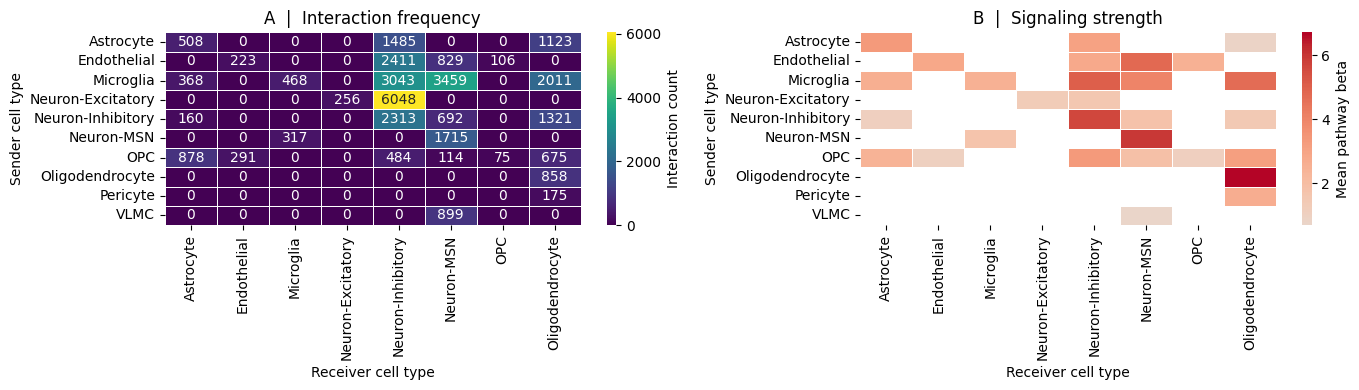

In [18]:
# Count of interactions
count_mat = (
    df_all
    .groupby(['sender_type', 'receiver_type'])
    .size()
    .unstack(fill_value=0)
)
#count_mat = count_mat.reindex(index=cell_types, columns=cell_types, fill_value=0)

# Mean beta (signaling strength)
mean_beta_mat = (
    df_all
    .groupby(['sender_type', 'receiver_type'])['beta']
    .mean()
    .unstack()
)

# Force same full matrix shape
#mean_beta_mat = mean_beta_mat.reindex(index=cell_types, columns=cell_types)

# Optional: mask low-count pairs in mean beta
min_n = 3
mean_beta_masked = mean_beta_mat.mask(count_mat < min_n)
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, max(4, 0.35 * count_mat.shape[0]))
)

# ============================
# Panel A — Count heatmap
# ============================
sns.heatmap(
    count_mat,
    ax=axes[0],
    cmap="viridis",
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    cbar_kws={"label": "Interaction count"}
)

axes[0].set_title("A  |  Interaction frequency")
axes[0].set_xlabel("Receiver cell type")
axes[0].set_ylabel("Sender cell type")

# ============================
# Panel B — Mean beta heatmap
# ============================
sns.heatmap(
    mean_beta_masked,
    ax=axes[1],
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Mean pathway beta"}
)

axes[1].set_title("B  |  Signaling strength")
axes[1].set_xlabel("Receiver cell type")
axes[1].set_ylabel("Sender cell type")  # shared y-axis

plt.tight_layout()
plt.show()



In [19]:
df = df = pd.read_csv(f"{OUT_DIR}/spacia_gene_pairs_filtered_ALL.csv")
df_unique = df.drop_duplicates(subset=["sender_gene", "receiver_gene"])


df_unique.to_csv(f"{OUT_DIR}/spacia_gene_pairs_unique_ALL.csv", index=False)

print("Unique directed LR pairs:", len(df_unique))
pairs = df_unique[['sender_gene', 'receiver_gene']]

for _, row in df_unique.sort_values(['sender_gene','receiver_gene']).iterrows():
    print(f"{row['sender_gene']} → {row['receiver_gene']}")

Unique directed LR pairs: 646
Adamts3 → Cd4
Adamts3 → Cma1
Adamts3 → Csf1r
Adamts3 → Efnb2
Adamts3 → Egfr
Adamts3 → Fads2
Adamts3 → Flt3
Adamts3 → Gad1
Adamts3 → Gad2
Adamts3 → Hes5
Adamts3 → Ifngr1
Adamts3 → Lamp5
Adamts3 → Ogt
Adamts3 → Pvalb
Adamts3 → Slc32a1
Adamts3 → Sst
Adamts3 → Stmn2
Agpat3 → Adora2a
Agpat3 → Crym
Agpat3 → Drd2
Agpat3 → Hes5
Agpat3 → Penk
Agpat4 → Agpat4
Agpat4 → Cdk5r1
Agpat4 → Cldn11
Agpat4 → Crym
Agpat4 → Enpp2
Agpat4 → Gad2
Agpat4 → Gpm6b
Agpat4 → Ifi27
Agpat4 → Klk6
Agpat4 → Mog
Agpat4 → Ogt
Agpat4 → Opalin
Agpat4 → Slc32a1
Agpat4 → Sparc
Agpat4 → Syt11
Alcam → Adamts3
Alcam → Cd47
Alcam → Cdk5r1
Alcam → Crym
Alcam → Efnb2
Aldh1l1 → Aldh1l1
Aldh1l1 → Gja1
Aldh1l1 → Hes5
Aldh1l1 → Tert
Aldh1l1 → Xcl1
Apod → Agpat4
Apod → Cldn11
Apod → Enpp2
Apod → Mog
Apod → Opalin
Apoe → Apoe
Apoe → Gfap
Apoe → H2-K1
Apoe → Pdcd1
Apoe → Thbs4
Atp1a2 → Atp1a2
Atp1a2 → Cnn3
Atp1a2 → Crym
Atp1a2 → Gja1
Atp1a2 → Gpm6b
Atp1a2 → Sirt6
Atp1a2 → Slc1a2
Atp1a2 → Sox9
Bmp4 → Adamts3

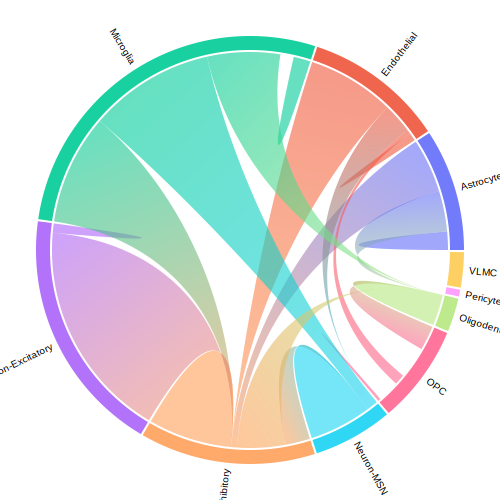

In [20]:
import os
import pandas as pd
import openchord as ocd

# 1️⃣ Generate matrices
count_mat = df_all.groupby(['sender_type', 'receiver_type']).size().unstack(fill_value=0)
sum_beta_mat = df_all.groupby(['sender_type', 'receiver_type'])['beta'].sum().unstack(fill_value=0)
mean_beta_mat = df_all.groupby(['sender_type', 'receiver_type'])['beta'].mean().unstack()

# 2️⃣ Save matrices
count_mat.to_csv(os.path.join(OUT_DIR, "matrix_count_combined.csv"))
sum_beta_mat.to_csv(os.path.join(OUT_DIR, "matrix_sum_beta_combined.csv"))
mean_beta_mat.to_csv(os.path.join(OUT_DIR, "matrix_mean_beta_combined.csv"))

# 3️⃣ Prepare labels in consistent order
senders = list(count_mat.index)
receivers = list(count_mat.columns)

# Combine sender and receiver labels for chord diagram labels
labels = senders + [r for r in receivers if r not in senders]

# 4️⃣ Build adjacency matrix for chord diagram
import numpy as np

# Initialize square matrix with zeros
size = len(labels)
adjacency_matrix = np.zeros((size, size))

# Fill in sender->receiver values in appropriate matrix positions
for i, sender in enumerate(senders):
    for j, receiver in enumerate(receivers):
        sender_idx = labels.index(sender)
        receiver_idx = labels.index(receiver)
        adjacency_matrix[sender_idx, receiver_idx] = count_mat.loc[sender, receiver]

# 5️⃣ Create chord diagram
fig = ocd.Chord(adjacency_matrix.tolist(), labels)

# 6️⃣ Optional: Set colors (make sure you have enough for all labels)
fig.colormap = [
    '#636EFA', '#EF553B', '#00CC96', '#AB63FA',
    '#FFA15A', '#19D3F3', '#FF6692', '#B6E880',
    '#FF97FF', '#FECB52', '#8A2BE2', '#FF4500', '#2E8B57'
][:len(labels)]  # truncate or extend as needed

# 7️⃣ Show the plot
fig.show()


### cell-type interaction strength based on significant Spacia interactions

In [21]:
# Save Spacia final cell-type interaction matrix
spacia_mat = mean_beta_masked.copy()
spacia_mat.to_csv("/home/akram/share/Multiple_Grids/Spacia/Results/Spacia_celltype_matrix.csv")
print("Saved: Spacia_celltype_matrix.csv")

Saved: Spacia_celltype_matrix.csv
